# Stage 1: Run a pretrained detector (an afternoon)
Goal: see what detection output looks like before learning how it works.

1. Run YOLO (yolo11n.pt, the smallest) on your test images with ultralytics
2. Draw boxes yourself with OpenCV/matplotlib from the raw results (don't just use .plot())
3. Print the raw outputs: boxes, class ids, confidences
4. Vary the confidence threshold (0.1, 0.25, 0.5, 0.75) and watch false positives/negatives change
5. Try a webcam or video file with the same model
Questions to answer:

What are the 80 COCO classes, and what happens with objects that aren't among them?
Where does it fail on your hard images, and why?
How does speed differ between yolo11n and yolo11m on your CPU?

In [4]:
from ultralytics import YOLO
from PIL import Image

In [5]:
model = YOLO("yolo11n.pt")

results = model("../images/1.jpg")


image 1/1 c:\Users\61417\Documents\misc_projects\image_analysis\notebooks\..\images\1.jpg: 448x640 1 bear, 222.0ms
Speed: 14.0ms preprocess, 222.0ms inference, 22.5ms postprocess per image at shape (1, 3, 448, 640)


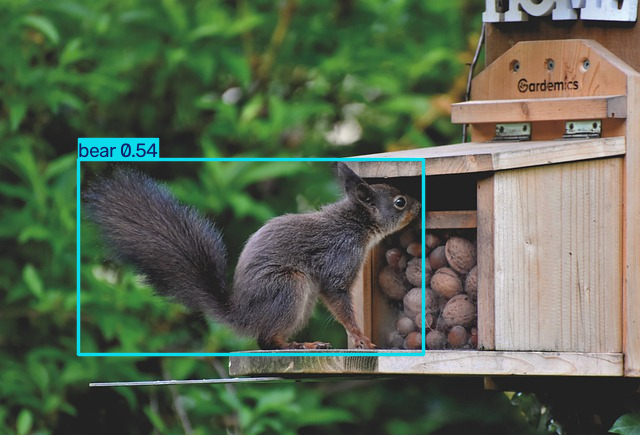

In [9]:
im_array = results[0].plot()
im = Image.fromarray(im_array[...,::-1])
display(im)

In [13]:
for result in results:
    boxes = result.boxes
    for box in boxes:
        conf = box.conf[0].item()
        cls = int(box.cls[0].item())
        class_name = model.names[cls]

        print(f"Object: {class_name}; Confidence: {conf:.2f}")

Object: bear; Confidence: 0.54


In [11]:
results[0].names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

Looking at raw bounding box probs - Mouse is not viewed as being at all likely, but Bear is a bit likely. Apparently YOLO uses 1 Logit model per class rather than a sigmoid multi-class prediction

In [ ]:
import torch
boxes = results[0].boxes
# 1. Get the image array
orig_img = results[0].orig_img

# 2. Format properly: Reorder dimensions to [C, H, W], add batch dim, and normalize to 0.0-1.0
preprocessed_tensor = model.predictor.preprocess([orig_img])
# 3. Send to the same device as your model (CPU or CUDA)
img_tensor = preprocessed_tensor.to(model.device)

# 4. Run through the raw model
with torch.no_grad():
    raw_output = model.model(img_tensor)

predictions = raw_output[0].squeeze(0).T


for box in boxes:

    x1, y1, x2, y2 = box.xyxy[0]
    # first 4 entries are bounding box coords (?) then class scores
    all_class_scores = predictions[:, 4:]
    all_class_probs = torch.sigmoid(all_class_scores)

        # Find the row index where the max probability matches the box's highest conf index
    top_class_id = int(box.cls[0].item())
    
    # Filter anchors where this specific class is highly confident
    matched_anchor_idx = (all_class_probs[:, top_class_id] - box.conf[0]).abs().argmin()
    
    # Now you have the complete array of 80 class probabilities for THIS exact box!
    box_all_probs = all_class_probs[matched_anchor_idx]
    
    # Look up specific alternative classes
    bear_idx = model.names.index("bear") if "bear" in model.names else 21 
    mouse_idx = model.names.index("mouse") if "mouse" in model.names else 74
    
    print(f"Detected Box Match Conf: {box_all_probs[top_class_id].item():.4f}")
    print(f"--- Alternative Class Checks ---")
    print(f"Confidence if predicted Bear: {box_all_probs[bear_idx].item():.4f}")
    print(f"Confidence if predicted Mouse: {box_all_probs[mouse_idx].item():.4f}")


Detected Box Match Conf: 0.5404
--- Alternative Class Checks ---
Confidence if predicted Bear: 0.5404
Confidence if predicted Mouse: 0.5000


In [39]:
all_class_probs.size(), all_class_scores.size(), predictions.size()

(torch.Size([5880, 80]), torch.Size([5880, 80]), torch.Size([5880, 84]))

In [31]:
box_all_probs

tensor([0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5004, 0.5004, 0.5001, 0.5000, 0.5000, 0.5000, 0.5000, 0.5404, 0.5000, 0.5000, 0.5000, 0.5002, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000])

In [27]:
predictions.size()

torch.Size([5880, 84])